In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

!cp "/content/drive/MyDrive/Dataset.zip" "/content/"
!unzip -q "/content/Dataset.zip" -d "/content/"
print("Giải nén xong!")

Giải nén xong!


In [3]:
import cv2
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models.video as video_models
import os
import glob
import numpy as np

# Doc dataset
class BenchPressVideoDataset(Dataset):
    def __init__(self, root_dir, num_frames=16):
        self.root_dir = root_dir
        self.num_frames = num_frames

        self.classes = ['Len_Dung', 'Xuong_Dung', 'Len_Sai', 'Xuong_Sai']
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        self.video_paths = []
        self.labels = []

        for cls_name in self.classes:
            cls_dir = os.path.join(root_dir, cls_name)
            if not os.path.exists(cls_dir):
                print(f"Khong thay thu muc {cls_dir}")
                continue
            for video_path in glob.glob(os.path.join(cls_dir, '*.mp4')):
                self.video_paths.append(video_path)
                self.labels.append(self.class_to_idx[cls_name])

        print(f"load thanh cong {len(self.video_paths)} video tu {root_dir}")

    def __len__(self):
        return len(self.video_paths)

    def read_video(self, video_path):
        cap = cv2.VideoCapture(video_path)
        frames = []
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if total_frames > self.num_frames:
            frame_indices = np.linspace(0, total_frames - 1, self.num_frames, dtype=int)
        else:
            frame_indices = np.arange(self.num_frames) % total_frames if total_frames > 0 else [0]*self.num_frames

        current_frame = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
            if current_frame in frame_indices:
                #resize
                frame = cv2.resize(frame, (171, 128))
                #cat trung tam 112x112
                h, w, _ = frame.shape
                start_y = h // 2 - 56
                start_x = w // 2 - 56
                frame = frame[start_y:start_y+112, start_x:start_x+112]

                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(frame)
            current_frame += 1
            if len(frames) == self.num_frames: break
        cap.release()

        #Padding lai video neu thieu frame
        while len(frames) < self.num_frames:
            frames.append(np.zeros((112, 112, 3), dtype=np.uint8))

        frames = np.array(frames)
        frames = frames.transpose(3, 0, 1, 2) #(C, T, H, W)

        #Rescale [0.0, 1.0]
        tensor_frames = torch.FloatTensor(frames) / 255.0

        #normalize
        mean = torch.tensor([0.43216, 0.394666, 0.37645]).view(3, 1, 1, 1)
        std = torch.tensor([0.22803, 0.22145, 0.216989]).view(3, 1, 1, 1)
        tensor_frames = (tensor_frames - mean) / std

        return tensor_frames

    def __getitem__(self, idx):
        return self.read_video(self.video_paths[idx]), self.labels[idx]

# Khoi tao model ResNet3D_18
def get_3d_model(num_classes=4):
    model = video_models.r3d_18(weights='DEFAULT')

    # Giu nguyen lop dau
    for param in model.parameters():
        param.requires_grad = False

    # Thay the lop cuoi
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, num_classes)
    )
    return model

In [5]:
import torch.optim as optim
import time

#Cau hinh thong so
TRAIN_DIR = '/content/Dataset/train'
TEST_DIR = '/content/Dataset/test'

SAVE_PATH = '/content/drive/MyDrive/best_model_3d.pth'

BATCH_SIZE = 8
EPOCHS = 15
LR = 1e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training bang: {device}")

#Load dataset da duoc chia
train_dataset = BenchPressVideoDataset(root_dir=TRAIN_DIR, num_frames=16)
val_dataset = BenchPressVideoDataset(root_dir=TEST_DIR, num_frames=16)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

#Dam bao hoc dung 4 nhan
model = get_3d_model(num_classes=4).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.fc.parameters(), lr=LR)

best_val_acc = 0.0

#Vong lap hoc chinh
print("\nBat dau training")
for epoch in range(EPOCHS):
    start_time = time.time()

    #Train
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total if total > 0 else 0

    #Valid
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else 0
    val_acc = val_correct / val_total if val_total > 0 else 0

    #Luu model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        mark = " (Da luu)"
    else:
        mark = ""

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1:02d}/{EPOCHS} [{epoch_time:.0f}s] | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} {mark}")

print(f"\n training xong, model: {SAVE_PATH}")

Training bang: cuda
load thanh cong 1374 video tu /content/Dataset/train
load thanh cong 344 video tu /content/Dataset/test

Bat dau training
Epoch 01/15 [1040s] | Train Loss: 1.3025 Acc: 0.3916 | Val Loss: 1.3164 Acc: 0.3663  (Da luu)
Epoch 02/15 [1018s] | Train Loss: 1.1125 Acc: 0.5058 | Val Loss: 1.2627 Acc: 0.4651  (Da luu)
Epoch 03/15 [1012s] | Train Loss: 0.9673 Acc: 0.6295 | Val Loss: 1.1971 Acc: 0.5436  (Da luu)
Epoch 04/15 [1016s] | Train Loss: 0.8617 Acc: 0.6827 | Val Loss: 1.1693 Acc: 0.6017  (Da luu)
Epoch 05/15 [1014s] | Train Loss: 0.8092 Acc: 0.7111 | Val Loss: 1.1264 Acc: 0.5756 
Epoch 06/15 [1024s] | Train Loss: 0.7345 Acc: 0.7336 | Val Loss: 1.1089 Acc: 0.5727 
Epoch 07/15 [1026s] | Train Loss: 0.6848 Acc: 0.7722 | Val Loss: 1.1002 Acc: 0.6541  (Da luu)
Epoch 08/15 [1026s] | Train Loss: 0.6628 Acc: 0.7766 | Val Loss: 1.0768 Acc: 0.5930 
Epoch 09/15 [1033s] | Train Loss: 0.6252 Acc: 0.7940 | Val Loss: 1.0596 Acc: 0.6483 
Epoch 10/15 [1040s] | Train Loss: 0.5917 Acc: 0.

Load du lieu test
load thanh cong 344 video tu /content/Dataset/test
Waiting
Dang cham diem...

(CLASSIFICATION REPORT)
              precision    recall  f1-score   support

    Len_Dung     0.7778    0.1458    0.2456        96
  Xuong_Dung     0.6525    0.9583    0.7764        96
     Len_Sai     0.7059    0.9474    0.8090        76
   Xuong_Sai     0.9157    1.0000    0.9560        76

    accuracy                         0.7384       344
   macro avg     0.7630    0.7629    0.6967       344
weighted avg     0.7574    0.7384    0.6751       344


Confusion Matrix...


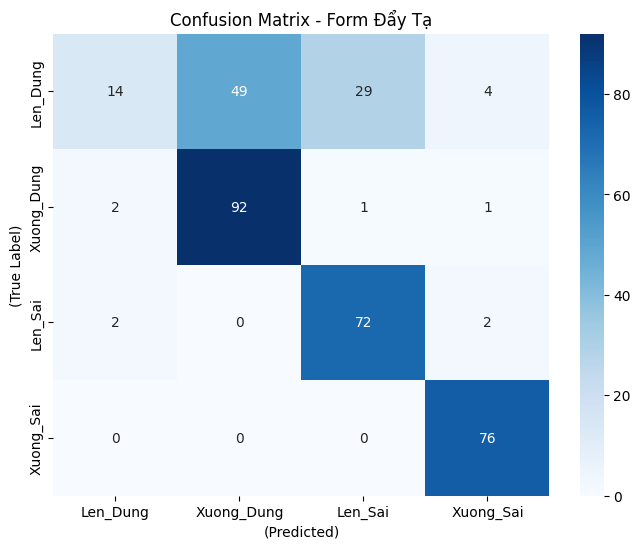

In [6]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

TEST_DIR = '/content/Dataset/test'
MODEL_PATH = '/content/drive/MyDrive/best_model_3d.pth'
CLASSES = ['Len_Dung', 'Xuong_Dung', 'Len_Sai', 'Xuong_Sai']

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Load du lieu test")
val_dataset = BenchPressVideoDataset(root_dir=TEST_DIR, num_frames=16)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print("Waiting")
model = get_3d_model(num_classes=len(CLASSES)).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()

#Cham diem model
all_preds = []
all_labels = []

print("Dang cham diem...")
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\n" + "="*55)
print("(CLASSIFICATION REPORT)")
print("="*55)
report = classification_report(all_labels, all_preds, target_names=CLASSES, digits=4)
print(report)

print("\nConfusion Matrix...")
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix - Form Đẩy Tạ')
plt.xlabel('(Predicted)')
plt.ylabel('(True Label)')
plt.show()